In [587]:
import numpy as np

In [588]:
def mini_batching(X, Y, batch_size):
    m = X.shape[1]
    batch = []
    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((Y.shape[0], m))

    complete_batches = m // batch_size
    for i in range(0, complete_batches):
        batch_X = shuffled_X[:, i * batch_size:(i + 1) * batch_size]
        batch_Y = shuffled_Y[:, i * batch_size:(i + 1) * batch_size]
        mini_batch = (batch_X, batch_Y)
        batch.append(mini_batch)
    if m % batch_size != 0:
        batch_X = shuffled_X[:, batch_size * complete_batches:]
        batch_Y = shuffled_Y[:, batch_size * complete_batches:]
        mini_batch = (batch_X, batch_Y)
        batch.append(mini_batch)
    return batch

In [589]:
def initialize_parameters(layer_dims):
    parameters = {}
    L = len(layer_dims)
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layer_dims[l], layer_dims[l - 1]) * np.sqrt(2) / layer_dims[l - 1] 
        parameters['b' + str(l)] = np.zeros((layer_dims[l], 1))
        if l < L - 1:
            parameters['gamma' + str(l)] = np.ones((layer_dims[l], 1))
            parameters['beta' + str(l)] = np.zeros((layer_dims[l], 1))
    return parameters

In [590]:
def batch_norm_forward(Z, gamma, beta, epsilon = 1e-7):
    mu = np.mean(Z, axis = 1, keepdims = True)
    xmu = Z - mu
    var = np.mean(xmu**2, axis = 1, keepdims = True)
    sqrt_var = np.sqrt(var + epsilon)
    ivar = 1.0 / sqrt_var

    Z_norm = xmu * ivar

    Z_tilde = gamma * Z_norm + beta

    b_cache = (Z_norm, xmu, ivar, sqrt_var, var, mu, gamma)
    return Z_tilde, b_cache

In [591]:
def forward_pass(X, parameters, batch_norm_forward):
    cache = {}
    cache['A0'] = X
    L = len([k for k in parameters.keys() if k.startswith('W')])
    for l in range(1, L):
        Z = np.dot(parameters['W' + str(l)], cache['A' + str(l - 1)]) + parameters['b' + str(l)]
        Z_tilde, b_cache = batch_norm_forward(Z, parameters['gamma' + str(l)], parameters['beta' + str(l)])
        cache['Z' + str(l)] = Z
        cache['Z_tilde' + str(l)] = Z_tilde
        cache['b_cache' + str(l)] = b_cache
        cache['A' + str(l)] = np.maximum(0, Z_tilde)
    ZL = np.dot(parameters['W' + str(L)], cache['A' + str(L - 1)]) + parameters['b' + str(L)]
    cache['Z' + str(L)] = ZL
    cache['A' + str(L)] = 1 / (1.0 + np.exp(-ZL))
    AL = cache['A' + str(L)]
    return AL, cache

In [592]:
def batch_backprop(dZ_tilde, cache, parameters):
    Z_norm, xmu, ivar, sqrtvar, var, mu, gamma = cache
    m = dZ_tilde.shape[1]

    dbeta = np.sum(dZ_tilde, axis = 1, keepdims = True)
    dgamma = np.sum(dZ_tilde * Z_norm, axis = 1, keepdims = True)
    dZ_norm = dZ_tilde * gamma

    divar = np.sum(dZ_norm * xmu, axis = 1, keepdims= True)
    dsqrtvar = divar * (- 1.0 / np.square(sqrtvar))
    dvar = np.sum(dsqrtvar) * (1.0 / (2 * sqrtvar))
    dxmu = dZ_norm * ivar + (2 * dvar * xmu) / m
    dmu = np.sum(dxmu * (- 1.0), axis = 1, keepdims = True)

    dZ = dxmu + dmu * 1/m

    return dZ, dgamma, dbeta

In [593]:
def backprop(X, Y, parameters, AL, cache):
    m = Y.shape[1]
    L = len([k for k in parameters.keys() if k.startswith('W')])
    grads = {}
    dZL =  AL - Y
    grads['dW' + str(L)] = (1.0 / m) * np.dot(dZL, cache['A' + str(L - 1)].T)
    grads['db' + str(L)] = (1.0 / m) * np.sum(dZL, axis = 1, keepdims = True)
    grads['dA' + str(L - 1)] = np.dot(parameters['W' + str(L)].T, dZL)
    for l in reversed(range(1, L)):
        dZ_tilde = np.copy(grads['dA' + str(l)])
        dZ_tilde[cache['Z_tilde' + str(l)] <= 0] = 0
        grads['dZ_tilde' + str(l)] = dZ_tilde
        dZ, dgamma, dbeta = batch_backprop(grads['dZ_tilde' + str(l)], cache['b_cache' + str(l)], parameters)
        grads['dZ' + str(l)] = dZ
        grads['dgamma' + str(l)] = dgamma
        grads['dbeta' + str(l)] = dbeta
        grads['dW' + str(l)] = (1.0 / m) * np.dot(grads['dZ' + str(l)], cache['A' + str(l - 1)].T)
        grads['dA' + str(l - 1)] = np.dot(parameters['W' + str(l)].T, grads['dZ' + str(l)])
        grads['db' + str(l)] = (1.0 / m) * np.sum(grads['dZ' + str(l)], axis=1, keepdims=True)

    return grads

In [594]:
def update_params(parameters, grads, learning_rate= 0.01):
    L = len([k for k in parameters.keys() if k.startswith('W')])
    for l in range(1, L + 1):
        parameters['W' + str(l)] -= learning_rate * grads['dW' + str(l)]
        parameters['b' + str(l)] -= learning_rate * grads['db' + str(l)]
        if l < L - 1:
            parameters['gamma' + str(l)] -= learning_rate * grads['dgamma' + str(l)]
            parameters['beta' + str(l)] -= learning_rate * grads['dbeta' + str(l)]
            
    return parameters

In [595]:
def compute_cost(AL, Y):
    m = Y.shape[1]
    AL = np.clip(AL, 1e-15, 1.0 - 1e-15)
    cost = (- 1.0 / m) * np.sum(Y*np.log(AL) + (1 - Y) * np.log(1 - AL))
    return np.squeeze(cost)

In [596]:
from sklearn.datasets import make_moons

In [597]:
X_raw, Y_raw = make_moons(500, noise = 0.2, random_state = 42)

In [598]:
from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(X_raw, Y_raw, test_size = 0.2, random_state = 42)
X_train = X_train_raw.T
X_test = X_test_raw.T
Y_train = Y_train_raw.reshape(1, -1)
Y_test = Y_test_raw.reshape(1, -1)

In [599]:
def model(X, Y, layer_dims, num_epochs = 1000, batch = 64, learning_rate = 0.01):
    parameters = initialize_parameters(layer_dims)
    for i in range(num_epochs):
        minibatches = mini_batching(X, Y, batch)
        for minibatch in minibatches:
            X_mini, Y_mini = minibatch
            AL, cache = forward_pass(X_mini, parameters, batch_norm_forward)
            batch_cost = compute_cost(AL, Y_mini)
            epoch_cost = batch_cost / batch
            grads = backprop(X_mini, Y_mini, parameters, AL, cache)
            parameters = update_params(parameters, grads, learning_rate)
        if i % 100 == 0:
            print(f'Cost after iteration {i} is {epoch_cost}')
    return parameters

In [600]:
parameters = model(X_train, Y_train, layer_dims = [2, 20, 10, 1])

Cost after iteration 0 is 0.011480493703253861
Cost after iteration 100 is 0.009062083711148021
Cost after iteration 200 is 0.007720031233352111
Cost after iteration 300 is 0.008117168990246618
Cost after iteration 400 is 0.008726740743997154
Cost after iteration 500 is 0.007417296485401823
Cost after iteration 600 is 0.006881078762798172
Cost after iteration 700 is 0.007788238254937589
Cost after iteration 800 is 0.009909615725283372
Cost after iteration 900 is 0.010872427914677955


In [601]:
def predict(X, parameters):
    AL, _ = forward_pass(X, parameters, batch_norm_forward)
    predictions = (AL >= 0.5).astype(int)
    return predictions

In [602]:
predictions = predict(X_train, parameters)
predictions

array([[1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
        1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
        1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
        0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
        1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
        0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
        1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
        0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
        0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
        0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
        0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 

In [603]:
predictions == Y_train

array([[False, False, False,  True,  True, False, False,  True,  True,
        False,  True,  True, False, False, False, False, False, False,
        False, False, False, False, False,  True, False, False, False,
        False, False, False, False,  True,  True, False,  True,  True,
        False, False,  True, False, False, False, False, False, False,
        False, False,  True, False, False, False, False, False, False,
         True, False, False, False, False, False, False, False,  True,
        False, False, False, False, False,  True, False, False, False,
        False, False, False, False,  True, False, False, False, False,
        False, False, False, False, False,  True,  True,  True, False,
        False, False, False, False, False, False,  True, False,  True,
        False,  True, False, False, False,  True, False,  True, False,
         True, False, False,  True, False, False, False, False, False,
        False,  True, False,  True, False, False, False,  True,  True,
      

In [604]:
import matplotlib.pyplot as plt
def plot_decision_boundary(model_predict, X, Y):
    x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
    y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
    h = 0.02 

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()].T
    
    Z = model_predict(grid_points)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[0, :], X[1, :], c=Y.ravel(), cmap=plt.cm.Spectral, edgecolors='k')
    plt.show()

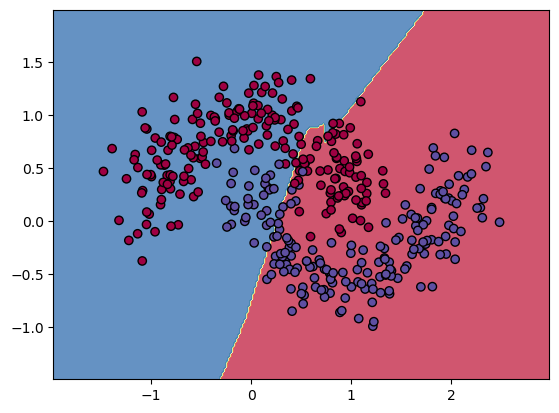

In [605]:
plot_decision_boundary(lambda x: predict(x, parameters), X_train, Y_train)